In [1]:
import os
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import torch
from torch.utils.data import Dataset, DataLoader,Subset
import torch.nn as nn
import sys
import seaborn as sns
import umap
import pickle


/var/folders/n5/n70ktbxj0kb1k0jzdktwjjth0000gn/T/ipykernel_4452/693801984.py:1: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium("/Users/varshinisakthi/Downloads/visium_brain_project")
/opt/anaconda3/envs/spaformer/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/anaconda3/envs/spaformer/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/var/folders/n5/n70ktbxj0kb1k0jzdktwjjth0000gn/T/ipykernel_4452/693801984.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata)


AnnData object with n_obs × n_vars = 2797 × 32285
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
(2797, 32285)
[[ 9621  7317]
 [ 9078  2989]
 [ 5538 10072]
 [ 9272  8639]
 [10520  6718]]


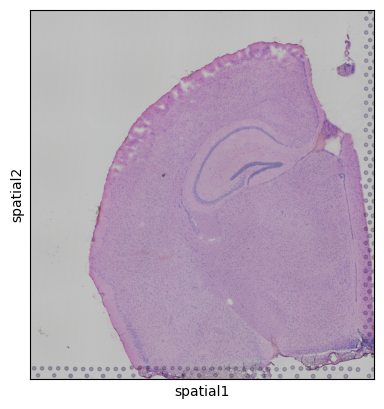

AnnData object with n_obs × n_vars = 2797 × 32285
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


In [2]:
adata = sc.read_visium("/Users/varshinisakthi/Downloads/visium_brain_project")
print(adata)
print(adata.X.shape)
print(adata.obsm["spatial"][:5])

sc.pl.spatial(adata)
adata.var_names_make_unique()
print(adata)
adata.write("/Users/varshinisakthi/Downloads/visium_brain_project/visium_brain_raw.h5ad")


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


                    total_counts  n_genes_by_counts  pct_counts_mt
AAACAAGTATCTCCCA-1       12245.0               4252      15.941201
AAACAGAGCGACTCCT-1       14372.0               4448      17.005289
AAACAGTGTTCCTGGG-1        9081.0               3080      32.672615
AAACATTTCCCGGATT-1        7249.0               2592      23.244585
AAACCCGAACGAAATC-1       14425.0               4549      13.365685


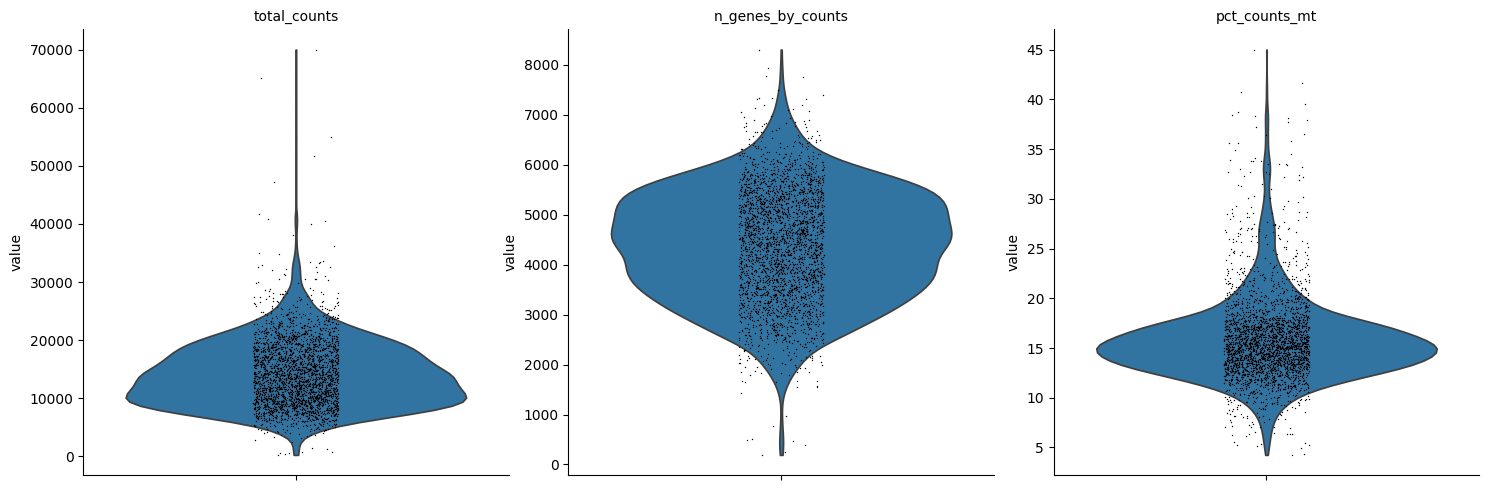

(2796, 2000)
AnnData object with n_obs × n_vars = 2796 × 2000
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'spatial', 'log1p', 'hvg'
    obsm: 'spatial'
[[ 9621  7317]
 [ 9078  2989]
 [ 5538 10072]
 [ 9272  8639]
 [10520  6718]]
Expression shape: (2796, 2000)
Coordinate shape: (2796, 2)
Query spot index: 0
Query coordinates: [9621 7317]
Neighbors including self: [   0  271 1566 2718 1757  336  774]
Distances including self: [  0.         138.         138.42

In [3]:
# Basic QC metrics
adata.var["mt"] = adata.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
print(adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].head())

# Visualize QC
sc.pl.violin(
    adata,
    ["total_counts", "n_genes_by_counts", "pct_counts_mt"],
    multi_panel=True)

# Preprocess
# Filter low-quality spots/genes
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Normalize and log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Select highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# Keep only HVGs
adata = adata[:, adata.var["highly_variable"]].copy()

print(adata.shape)
adata.write("/Users/varshinisakthi/Downloads/visium_brain_project/visium_brain_hvg.h5ad")
print(adata)
print(adata.obsm["spatial"][:5])

# Get expression matrix and coordinates
X = adata.X
#convert sparse matrix to dense if needed
if not isinstance(X, np.ndarray):
    X = X.toarray()

coords = adata.obsm["spatial"]

print("Expression shape:", X.shape) # n_spots x n_genes
print("Coordinate shape:", coords.shape) # n_spots x 2

# Build k-nearest-neighbor neighborhoods
k = 6 # number of neighbors per spot
nbrs = NearestNeighbors(n_neighbors=k+1, metric="euclidean")
nbrs.fit(coords)

distances, indices = nbrs.kneighbors(coords)

# Inspect one example
spot_idx = 0
print("Query spot index:", spot_idx)
print("Query coordinates:", coords[spot_idx])
print("Neighbors including self:", indices[spot_idx])
print("Distances including self:", distances[spot_idx])

# Remove self and build the actual neighbor matrix
neighbor_indices = indices[:, 1:]
neighbor_distances = distances[:, 1:]
print("Neighbor index matrix shape:", neighbor_indices.shape)
print("Neighbor distance matrix shape:", neighbor_distances.shape)
print("Spot 0 real neighbors:", neighbor_indices[0])
print("Spot 0 real neighbor distances:", neighbor_distances[0])


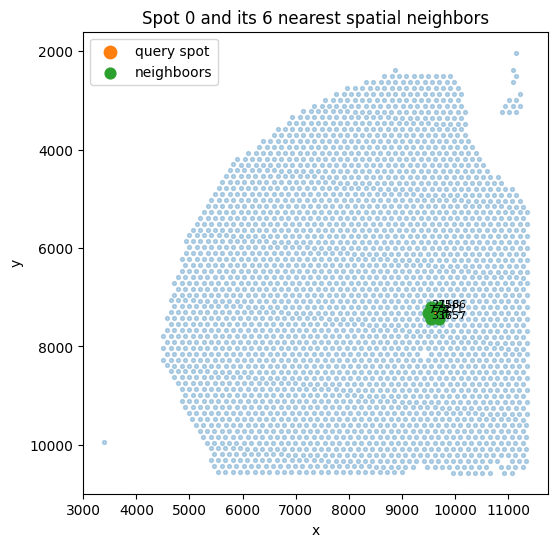

In [4]:
# Debugging step: visualize one query spot and its neighbors
spot_idx = 0
query_coord = coords[spot_idx]
nbr_idx = neighbor_indices[spot_idx]
nbr_coords = coords[nbr_idx]

plt.figure(figsize=(6, 6))

# all spots in light gray
plt.scatter(coords[:, 0], coords[:, 1], s=8, alpha=0.3)

# query spot in red
plt.scatter(query_coord[0], query_coord[1], s=80, label="query spot")

# neighbors in blue
plt.scatter(nbr_coords[:, 0], nbr_coords[:, 1], s=60, label="neighboors")

# label neighbor indices
for i, idx in enumerate(nbr_idx):
    plt.text(nbr_coords[i, 0], nbr_coords[i, 1], str(idx), fontsize=8)

plt.gca().invert_yaxis()
plt.legend()
plt.title(f"Spot {spot_idx} and its 6 nearest spatial neighbors")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [5]:
# Transformer Input Tensors
# Normalize spatial coordinates
coords_norm = coords.astype(np.float32).copy()
coords_norm[:, 0] = (coords_norm[:, 0] - coords_norm[:, 0].mean()) / coords_norm[:, 0].std()
coords_norm[:, 1] = (coords_norm[:, 1] - coords_norm[:, 1].mean()) / coords_norm[:, 1].std()

# Build sequences
n_spots, n_genes = X.shape
k = neighbor_indices.shape[1]
seq_len = k + 2 # CLS + query + neighbors
all_sequences = np.zeros((n_spots, seq_len, n_genes), dtype=np.float32)
all_spatial = np.zeros((n_spots, seq_len, 2), dtype=np.float32)
all_token_types = np.zeros((n_spots, seq_len), dtype=np.int64)

# Fill tensors
for i in range(n_spots):
    all_token_types[i, 0] = 0
    all_sequences[i, 1] = X[i]
    all_spatial[i, 1] = coords_norm[i]
    all_token_types[i, 1] = 1
    nbr_idx= neighbor_indices[i]
    all_sequences[i, 2:] = X[nbr_idx]
    all_spatial[i, 2:] = coords_norm[nbr_idx]
    all_token_types[i, 2:] = 2

# Verify
print(all_sequences.shape)
print(all_spatial.shape)
print(all_token_types.shape)

(2796, 8, 2000)
(2796, 8, 2)
(2796, 8)


In [6]:
# Clustering

clusters = pd.read_csv("/Users/varshinisakthi/Downloads/analysis/clustering/gene_expression_graphclust/clusters.csv")
clusters = clusters.rename(columns={"Barcode": "barcode", "Cluster": "label"})
clusters["barcode"] = clusters["barcode"].astype(str)
cluster_map = dict(zip(clusters["barcode"], clusters["label"]))
adata.obs["barcode"] = adata.obs_names.astype(str)
adata.obs["label"] = adata.obs["barcode"].map(cluster_map)

print(adata.obs[["barcode", "label"]].head())
print("Missing labels:", adata.obs["label"].isna().sum())

le = LabelEncoder()
y = le.fit_transform(adata.obs["label"])
print("Classes:", le.classes_)
print("Label shape:", y.shape)

                               barcode  label
AAACAAGTATCTCCCA-1  AAACAAGTATCTCCCA-1      7
AAACAGAGCGACTCCT-1  AAACAGAGCGACTCCT-1      2
AAACAGTGTTCCTGGG-1  AAACAGTGTTCCTGGG-1      1
AAACATTTCCCGGATT-1  AAACATTTCCCGGATT-1      5
AAACCCGAACGAAATC-1  AAACCCGAACGAAATC-1      5
Missing labels: 0
Classes: [ 1  2  3  4  5  6  7  8  9 10]
Label shape: (2796,)


In [7]:
# PyTorch 

class SpatialDataset(Dataset):
    def __init__(self, seq, spatial, token_type, labels):
        self.seq = torch.tensor(seq, dtype=torch.float32)
        self.spatial = torch.tensor(spatial, dtype=torch.float32)
        self.token_type = torch.tensor(token_type, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "expression": self.seq[idx],
            "spatial": self.spatial[idx],
            "token_type": self.token_type[idx],
            "label": self.labels[idx],
        }

dataset = SpatialDataset(all_sequences, all_spatial, all_token_types, y)

sample = dataset[0]
print(sample["expression"].shape)
print(sample["spatial"].shape)
print(sample["token_type"])
print(sample["label"])

torch.Size([8, 2000])
torch.Size([8, 2])
tensor([0, 1, 2, 2, 2, 2, 2, 2])
tensor(6)


In [8]:
# Add train/validation split
indices = np.arange(len(dataset))
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=y,
    random_state=42
)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

batch =next(iter(train_loader))
print(batch["expression"].shape) # [B, seq_len, n_genes]
print(batch["spatial"].shape) # [B, seq_len, 2]
print(batch["token_type"].shape) # [B, seq_len]
print(batch["label"].shape) # [B]

torch.Size([16, 8, 2000])
torch.Size([16, 8, 2])
torch.Size([16, 8])
torch.Size([16])


In [9]:
# Small fast Transformer
class SpatialTransformer(nn.Module):
    def __init__(
        self,
        input_dim,
        num_classes,
        embed_dim=64,
        num_heads=4,
        num_layers=2,
        ff_dim=128,
        dropout=0.1,
        max_token_types=3
    ):
        super().__init__()

        self.expr_proj = nn.Linear(input_dim, embed_dim)
        self.spatial_proj = nn.Linear(2, embed_dim)
        self.token_embed = nn.Embedding(max_token_types, embed_dim)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, expression, spatial, token_type):
        expr_emb = self.expr_proj(expression)
        spatial_emb = self.spatial_proj(spatial)
        token_emb = self.token_embed(token_type)

        x = expr_emb + spatial_emb + token_emb
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x[:, 0:1, :] = cls

        x = self.transformer(x)
        cls_out = self.norm(x[:, 0, :])
        logits = self.classifier(cls_out)
        return logits

# Test one forward pass

device = torch.device("cpu")

model = SpatialTransformer(
    input_dim=batch["expression"].shape[-1],
    num_classes=len(np.unique(y)),
    embed_dim=64,
    num_heads=4,
    num_layers=2,
    ff_dim=128
).to(device)

batch = {k: v.to(device) for k, v in batch.items()}

logits = model(
    batch["expression"],
    batch["spatial"],
    batch["token_type"]
)
print("Expression shape:", batch["expression"].shape)
print("Spatial shape:", batch["spatial"].shape)
print("Token type shape:", batch["token_type"].shape)
print("Logits shape:", logits.shape) 
        

Expression shape: torch.Size([16, 8, 2000])
Spatial shape: torch.Size([16, 8, 2])
Token type shape: torch.Size([16, 8])
Logits shape: torch.Size([16, 10])


In [10]:
# One training step

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

def evaluate (model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    val_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(batch["expression"], batch["spatial"], batch["token_type"])
            loss = criterion(logits, batch["label"])
            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["label"].cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return val_loss / len(loader), acc, macro_f1

num_epochs = 30
best_f1 = 0.0
patience, patience_counter = 10, 0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

os.makedirs("checkpoints", exist_ok=True)

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0    
    for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()
            logits = model(batch["expression"], batch["spatial"], batch["token_type"])
            loss = criterion(logits, batch["label"])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

    avg_train = train_loss / len(train_loader)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, device)

    history["train_loss"].append(avg_train)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch+1:02d} | Train {avg_train:.4f} | Val loss {val_loss:.4f} | Acc {val_acc:.4f} | F1 {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        patience_counter = 0
        torch.save({
            "model_state": model.state_dict(),
            "config": {"input_dim": 2000, "num_classes": 10, "embed_dim": 64,
                      "num_heads": 4, "num_layers": 2, "ff_dim": 128},
            "label_classes": le.classes_.tolist()
        }, "checkpoints/best_model.pt")
        print(f" YES, New best saved (F1={best_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
            

Epoch 01 | Train 0.8329 | Val loss 0.4792 | Acc 0.8375 | F1 0.8212
 YES, New best saved (F1=0.8212)
Epoch 02 | Train 0.3516 | Val loss 0.4431 | Acc 0.8625 | F1 0.8450
 YES, New best saved (F1=0.8450)
Epoch 03 | Train 0.2104 | Val loss 0.3538 | Acc 0.8893 | F1 0.8816
 YES, New best saved (F1=0.8816)
Epoch 04 | Train 0.1415 | Val loss 0.5443 | Acc 0.8464 | F1 0.8171
Epoch 05 | Train 0.0882 | Val loss 0.4574 | Acc 0.8679 | F1 0.8492
Epoch 06 | Train 0.0432 | Val loss 0.4888 | Acc 0.8839 | F1 0.8625
Epoch 07 | Train 0.0152 | Val loss 0.3969 | Acc 0.9107 | F1 0.9023
 YES, New best saved (F1=0.9023)
Epoch 08 | Train 0.0053 | Val loss 0.4204 | Acc 0.8946 | F1 0.8861
Epoch 09 | Train 0.0135 | Val loss 0.6879 | Acc 0.8607 | F1 0.8509
Epoch 10 | Train 0.0619 | Val loss 0.8750 | Acc 0.8357 | F1 0.8323
Epoch 11 | Train 0.0377 | Val loss 0.5992 | Acc 0.8857 | F1 0.8699
Epoch 12 | Train 0.0106 | Val loss 0.5321 | Acc 0.9054 | F1 0.8994
Epoch 13 | Train 0.0287 | Val loss 0.6753 | Acc 0.8768 | F1 0.86

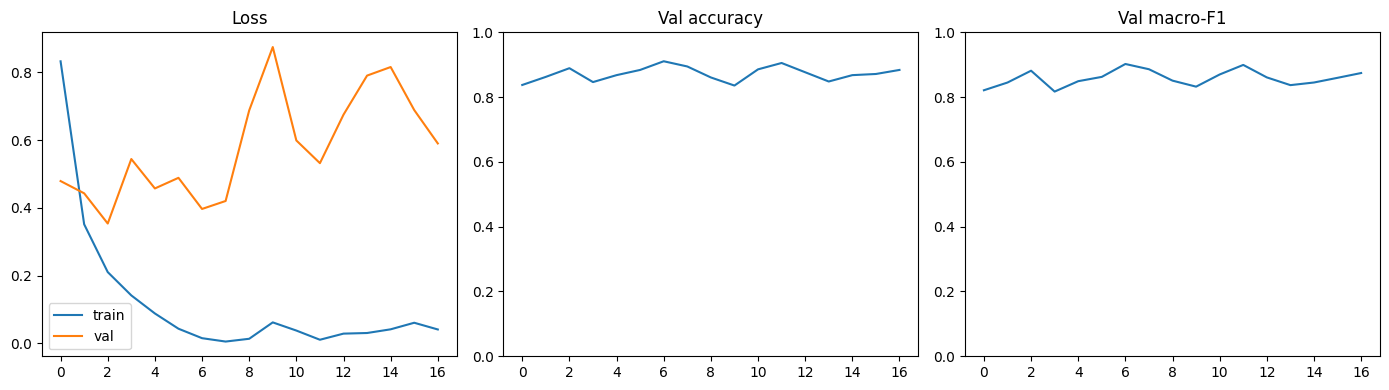

LogReg     | Acc 0.9232 | Macro-F1 0.9176
MLP        | Acc 0.9071 | Macro-F1 0.8928
XGBoost    | Acc 0.8982 | Macro-F1 0.8858

                        acc      f1
LogReg              0.9232  0.9176
MLP                 0.9071  0.8928
XGBoost             0.8982  0.8858
SpatialTransformer  0.9107  0.9023


In [11]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history["val_acc"])
axes[1].set_title("Val accuracy"); axes[1].set_ylim(0, 1)

axes[2].plot(history["val_f1"])
axes[2].set_title("Val macro-F1"); axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)

plt.show()

# Baselines 
X_train_flat = all_sequences[train_idx, 1, :]
X_val_flat = all_sequences[val_idx, 1, :]
y_train_base = y[train_idx]
y_val_base = y[val_idx]

baselines = {
    "LogReg": LogisticRegression(max_iter=500, C=1.0),
    "MLP": MLPClassifier(hidden_layer_sizes=(512, 256), max_iter=200),
    "XGBoost": XGBClassifier(n_estimators=300, max_delpth=6,
                             use_label_encoder=False, eval_metric="mlogloss",
                             verbosity=0),
}

results = {}
for name, clf in baselines.items():
    clf.fit(X_train_flat, y_train_base)
    preds = clf.predict(X_val_flat)
    acc = accuracy_score(y_val_base, preds)
    f1 = f1_score(y_val_base, preds, average="macro")
    results[name] = {"acc": acc, "f1": f1}
    print(f"{name:10s} | Acc {acc:.4f} | Macro-F1 {f1:.4f}")

# Add transformer result 
results["SpatialTransformer"] = {"acc": history["val_acc"][np.argmax(history["val_f1"])],
                                 "f1": best_f1}

results_df = pd.DataFrame(results).T
print("\n", results_df.round(4))
results_df.to_csv("baseline_results.csv")


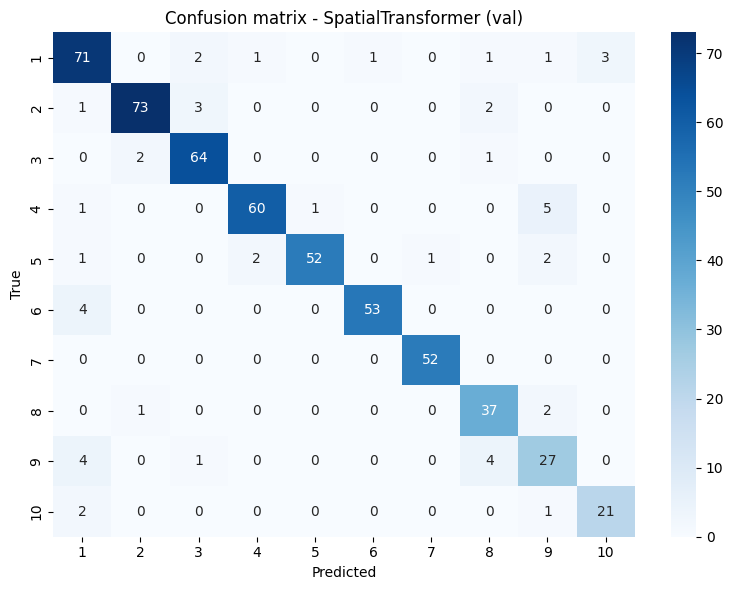

/opt/anaconda3/envs/spaformer/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


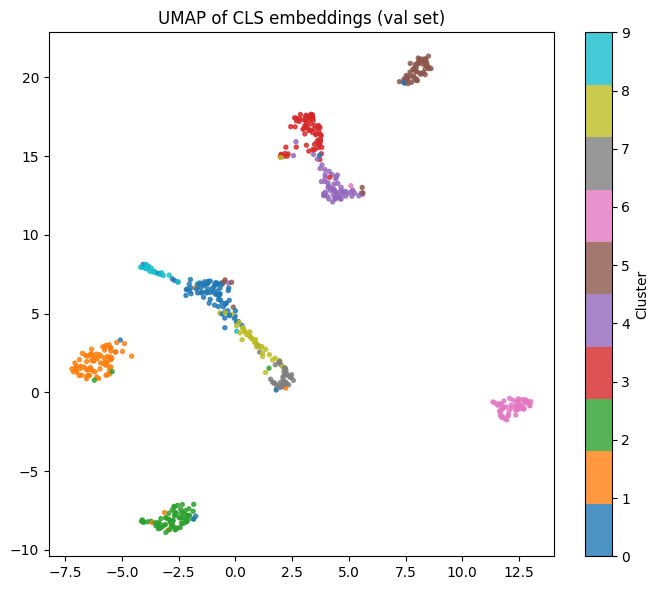

In [12]:
# Confusion matrix + UMAP of CLS embeddings
ckpt = torch.load("checkpoints/best_model.pt", map_location=device)
model.load_state_dict(ckpt["model_state"])

# Collect predictions and CLS embeddings on val set
model.eval()
all_preds, all_labels, cls_embeddings = [], [], []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(batch["expression"], batch["spatial"], batch["token_type"])

        # Extract CLS embedding (before classifier head)
        expr_emb = model.expr_proj(batch["expression"])
        spatial_emb = model.spatial_proj(batch["spatial"])
        token_emb = model.token_embed(batch["token_type"])
        x = expr_emb + spatial_emb + token_emb
        x[:, 0:1, :] = model.cls_token.expand(x.size(0), -1, -1)
        x = model.transformer(x)
        cls_out = model.norm(x[:, 0, :])
        cls_embeddings.append(cls_out.cpu().numpy())

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["label"].cpu().numpy())

cls_embeddings = np.concatenate(cls_embeddings, axis=0)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion matrix - SpatialTransformer (val)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42)
embedding_2d = reducer.fit_transform(cls_embeddings)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1],
                      c=all_labels, cmap="tab10", s=8, alpha=0.8)
plt.colorbar(scatter, label="Cluster")
plt.title("UMAP of CLS embeddings (val set)")
plt.tight_layout()
plt.savefig("umap_cls.png", dpi=150)
plt.show()

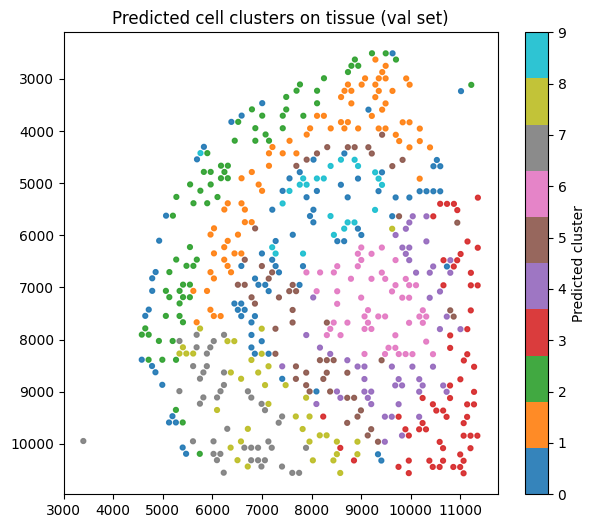

In [13]:
# Spatial prediction plot
# Predicted labels overlaid on tissue coordinates 

val_coords = coords[val_idx]
val_preds_arr = np.array(all_preds)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(val_coords[:, 0], val_coords[:, 1],
                      c=val_preds_arr, cmap="tab10", s=12, alpha=0.9)

plt.gca().invert_yaxis()
plt.colorbar(scatter, label="Predicted cluster")
plt.title("Predicted cell clusters on tissue (val set)")
plt.savefig("spatial_predictions.png", dpi=150)
plt.show()

In [14]:
# Save the full inference pipeline
torch.save({
    "model_state": model.state_dict(),
    "config": {"input_dim": 2000, "num_classes": 10, "embed_dim": 64,
              "num_heads": 4, "num_layers": 2, "ff_dim": 128},
    "label_classes": le.classes_.tolist(),
    "hvg_genes": adata.var_names.tolist(),
    "coords_mean": coords.mean(axis=0).tolist(),
    "coords_std": coords.std(axis=0).tolist(),
}, "checkpoints/inference_pipeline.pt")

with open("checkpoints/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Pipeline saved.")



Pipeline saved.


In [15]:
# Re-ru n XGBoost alone

xgb = XGBClassifier(n_estimators=300, max_depth=6,
                    eval_metric="mlogloss", verbosity=0)
xgb.fit(X_train_flat, y_train_base)
preds = xgb.predict(X_val_flat)
acc = accuracy_score(y_val_base, preds)
f1 = f1_score(y_val_base, preds, average="macro")
results["XGBoost"] = {"acc": acc, "f1": f1}
print(f"XGBoost | Acc{acc:.4f} | Macro-F1 {f1:.4f}")

# Update and re-save the results table

results["SpatialTransformer"] = {
    "acc": history["val_acc"][int(np.argmax(history["val_f1"]))],
    "f1": best_f1
}

results_df = pd.DataFrame(results).T
print("\n", results_df.round(4))
results_df.to_csv("baseline_results.csv")

XGBoost | Acc0.8982 | Macro-F1 0.8858

                        acc      f1
LogReg              0.9232  0.9176
MLP                 0.9071  0.8928
XGBoost             0.8982  0.8858
SpatialTransformer  0.9107  0.9023


In [16]:
# Attention weight extraction

model.eval()

all_cls_attn = []
all_val_labels = []
all_val_coords = []

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        expr_emb = model.expr_proj(batch["expression"])
        spatial_emb = model.spatial_proj(batch["spatial"])
        token_emb = model.token_embed(batch["token_type"])
        x = expr_emb + spatial_emb + token_emb
        x[:, 0:1, :] = model.cls_token.expand(x.size(0), -1, -1)

        for layer in model.transformer.layers:
            x2, attn_w = layer.self_attn(
                x, x, x,
                need_weights=True,
                average_attn_weights=True
            )
            x2 = layer.dropout1(x2)
            x = layer.norm1(x + x2)
            x2 = layer.linear2(layer.dropout(layer.activation(layer.linear1(x))))
            x2 = layer.dropout2(x2)
            x = layer.norm2(x + x2)

        cls_attn = attn_w[:, 0, :].cpu().numpy()
        all_cls_attn.append(cls_attn)
        all_val_labels.extend(batch["label"].cpu().numpy())

all_cls_attn = np.concatenate(all_cls_attn, axis=0)
all_val_labels = np.array(all_val_labels)

token_names = ["CLS", "Query"] + [f"Nbr {i}" for i in range(1, 7)]

print("Attention matrix shape:", all_cls_attn.shape)
print("Mean CLS attention per token:")
for name, val in zip(token_names, all_cls_attn.mean(axis=0)):
    print(f" {name:8s}: {val:.4f}")

Attention matrix shape: (560, 8)
Mean CLS attention per token:
 CLS     : 0.0575
 Query   : 0.7852
 Nbr 1   : 0.0261
 Nbr 2   : 0.0261
 Nbr 3   : 0.0264
 Nbr 4   : 0.0258
 Nbr 5   : 0.0268
 Nbr 6   : 0.0262


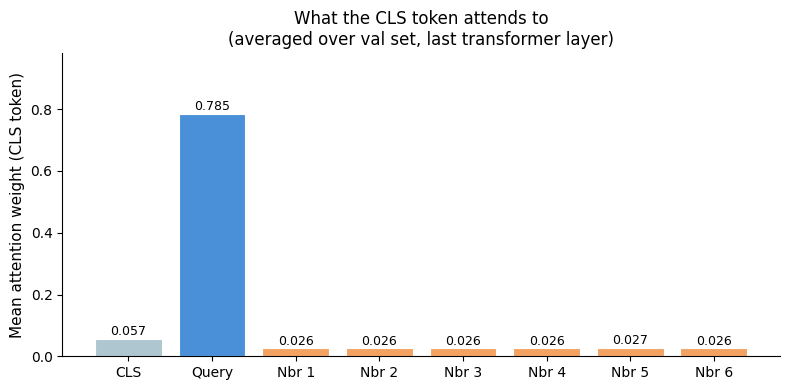

In [17]:
# Mean CLS attention bar chart
fig, ax = plt.subplots(figsize=(8, 4))

mean_attn = all_cls_attn.mean(axis=0)
colors = ["#aec6cf"] + ["#4a90d9"] + ["#f4a261"] * 6 

bars = ax.bar(token_names, mean_attn, color=colors, edgecolor="white", linewidth=0.8)

ax.set_ylabel("Mean attention weight (CLS token)", fontsize=11)
ax.set_title("What the CLS token attends to\n(averaged over val set, last transformer layer)", fontsize=12)
ax.set_ylim(0, mean_attn.max() * 1.25)

for bar, val in zip(bars, mean_attn):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("attn_mean_bar.png", dpi=150)
plt.show()

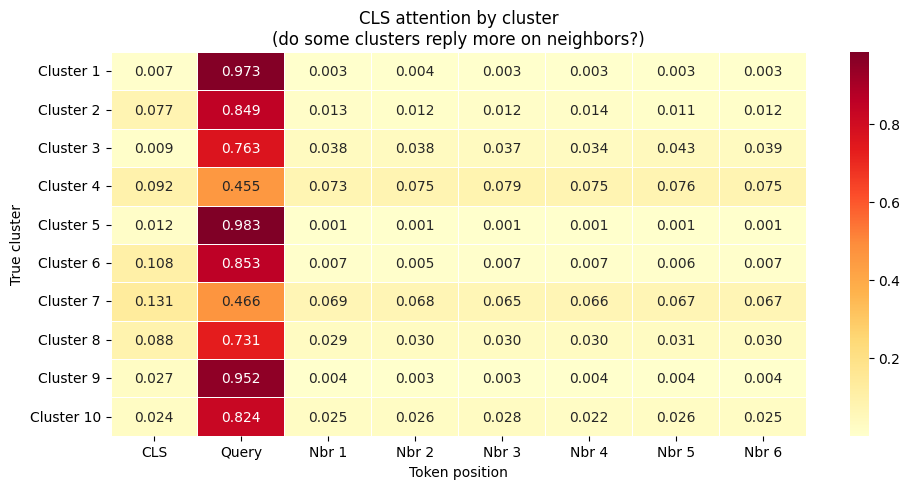

In [18]:
# Per-cluster attention heatmap
n_classes = len(le.classes_)
attn_by_class = np.zeros((n_classes, all_cls_attn.shape[1]))

for c in range(n_classes):
    mask = all_val_labels == c
    if mask.sum() > 0:
        attn_by_class[c] = all_cls_attn[mask].mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    attn_by_class,
    annot=True, fmt=".3f",
    xticklabels=token_names,
    yticklabels=[f"Cluster {c}" for c in le.classes_],
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax
)
ax.set_title("CLS attention by cluster\n(do some clusters reply more on neighbors?)", fontsize=12)
ax.set_xlabel("Token position")
ax.set_ylabel("True cluster")
plt.tight_layout()
plt.savefig("attn_by_cluster.png", dpi=150)
plt.show()
        

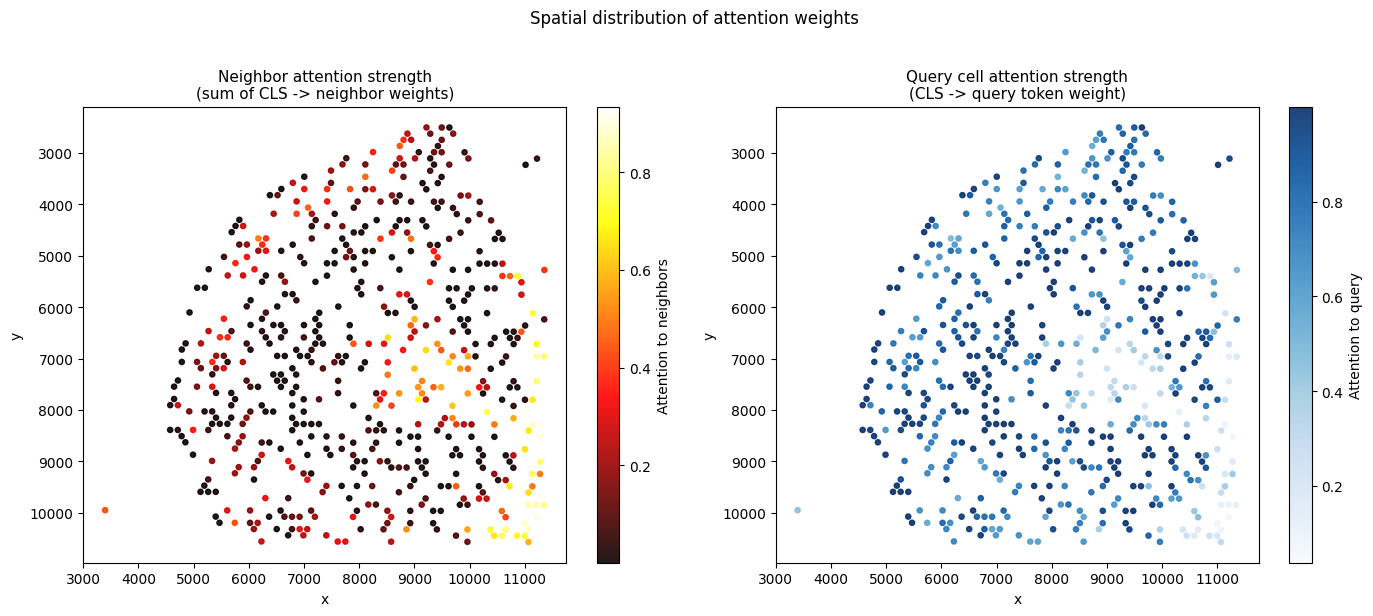

In [19]:
# Spatial attention map (neighbor weight on tissue)
neighbor_attn_sum = all_cls_attn[:, 2:].sum(axis=1)

val_coords_plot = coords[val_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: neighbor attention strength on tissue
sc0 = axes[0].scatter(
    val_coords_plot[:, 0], val_coords_plot[:, 1],
    c=neighbor_attn_sum, cmap="hot", s=14, alpha=0.9
)

axes[0].invert_yaxis()
axes[0].set_title("Neighbor attention strength\n(sum of CLS -> neighbor weights)", fontsize=11)
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
plt.colorbar(sc0, ax=axes[0], label="Attention to neighbors")

# Right: query cell attention strength on tissue
query_attn = all_cls_attn[:, 1]

sc1 = axes[1].scatter(
    val_coords_plot[:, 0], val_coords_plot[:, 1],
    c=query_attn, cmap="Blues", s=14, alpha=0.9
)
axes[1].invert_yaxis()
axes[1].set_title("Query cell attention strength\n(CLS -> query token weight)", fontsize=11)
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
plt.colorbar(sc1, ax=axes[1], label="Attention to query")

plt.suptitle("Spatial distribution of attention weights", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("spatial_attn_map.png", dpi=150, bbox_inches="tight")
plt.show()

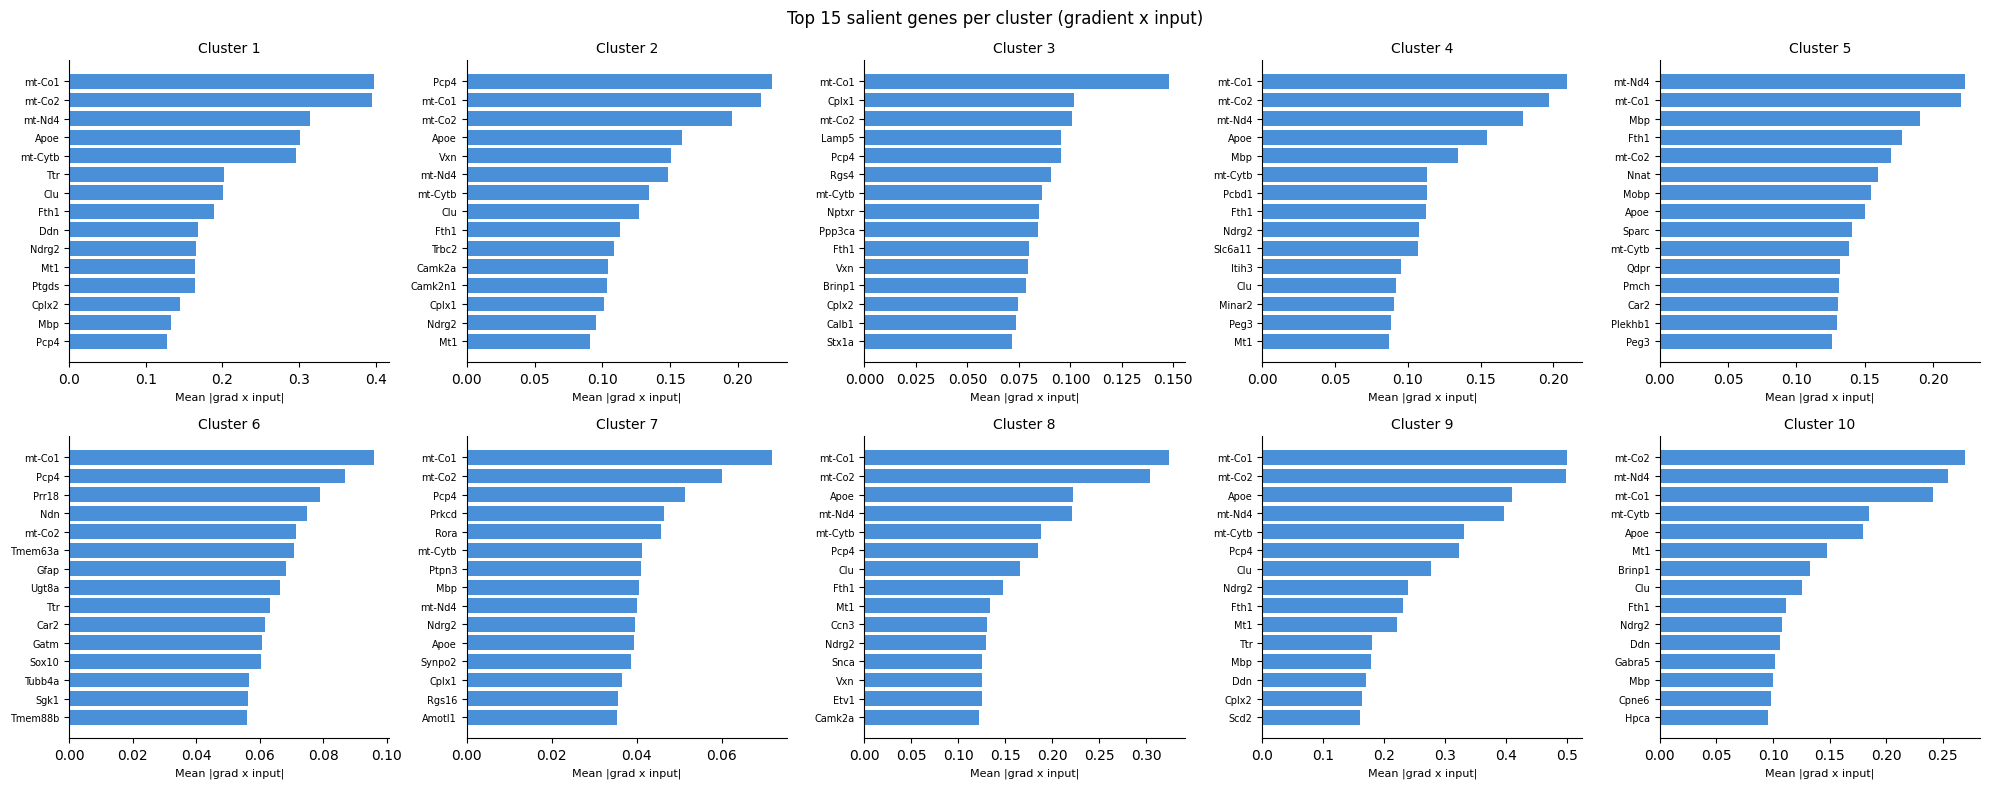

Saved:
 attn shape:     (560, 8)
 saliency shape:  (10, 2000)
 figures:    attn_mean_bar.png, attn_by_cluster.png,
             spatial_attn_map.png, gene_saliency.png


In [20]:
# Gene saliency (which genes drive predictions)

model.eval()
n_genes_hvg = 2000
class_saliency = np.zeros((n_classes, n_genes_hvg))

for target_class in range(n_classes):
    grads_accum = []

    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        mask = batch["label"] == target_class
        if mask.sum() == 0:
            continue

        expr = batch["expression"][mask].requires_grad_(True)
        sp = batch["spatial"][mask]
        tt = batch["token_type"][mask]

        logits = model(expr, sp, tt)
        score = logits[:, target_class].sum()
        score.backward()

        # Saliency = |gradient * input| at query cell position (token 1)
        saliency = (expr.grad[:, 1, :] * expr[:, 1, :]).abs()
        grads_accum.append(saliency.detach().cpu().numpy())

    if grads_accum:
        class_saliency[target_class] = np.concatenate(grads_accum, axis=0).mean(axis=0)

# Top 15 genes per cluster
hvg_names = np.array(adata.var_names.tolist())
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for c in range(n_classes):
    top_idx = np.argsort(class_saliency[c])[::-1][:15]
    top_vals = class_saliency[c][top_idx]
    top_genes = hvg_names[top_idx]

    axes[c].barh(top_genes[::-1], top_vals[::-1], color="#4a90d9")
    axes[c].set_title(f"Cluster {le.classes_[c]}", fontsize=10)
    axes[c].set_xlabel("Mean |grad x input|", fontsize=8)
    axes[c].tick_params(axis="y", labelsize=7)
    axes[c].spines[["top", "right"]].set_visible(False)

plt.suptitle("Top 15 salient genes per cluster (gradient x input)", fontsize=12)
plt.tight_layout()
plt.savefig("gene_saliency.png", dpi=150)
plt.show()

# Save all interpretation
np.save("checkpoints/val_cls_attn.npy", all_cls_attn)
np.save("checkpoints/val_labels.npy", all_val_labels)
np.save("checkpoints/val_coords.npy", val_coords_plot)
np.save("checkpoints/class_saliency.npy", class_saliency)
np.save("checkpoints/hvg_names.npy", hvg_names)

print("Saved:")
print(" attn shape:    ", all_cls_attn.shape)
print(" saliency shape: ", class_saliency.shape)
print(" figures:    attn_mean_bar.png, attn_by_cluster.png,")
print("             spatial_attn_map.png, gene_saliency.png")